# **1. PREPARATION**

## **1.1 IMPORT LIBRARIES**

In [103]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from tqdm import tqdm
from pathlib import Path
from datetime import datetime
from scipy.signal import savgol_filter
from sklearn.preprocessing import MinMaxScaler

pd.set_option('display.max_columns', None)

In [2]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.utils.class_weight import compute_class_weight

In [3]:
import keras
import tensorflow as tf
import tensorflow.keras.backend as K

from keras.models import Model

from keras.optimizers import SGD
from keras.optimizers import Adam
from keras.optimizers import Nadam

from keras.optimizers.schedules import ExponentialDecay
from keras.optimizers.schedules import CosineDecay

from tensorflow.keras.regularizers import l2
from tensorflow.keras.regularizers import l1
from tensorflow.keras.regularizers import l1_l2 

from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.losses import BinaryFocalCrossentropy

from tensorflow.keras.models import Sequential
from tensorflow.keras.models import load_model

from tensorflow.keras.utils import to_categorical

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau 

from tensorflow.keras.metrics import AUC
from tensorflow.keras.metrics import Recall
from tensorflow.keras.metrics import Precision 
from tensorflow.keras.metrics import TruePositives
from tensorflow.keras.metrics import TrueNegatives

from tensorflow.keras.layers import GRU
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Lambda
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.layers import Attention
from tensorflow.keras.layers import Activation
from tensorflow.keras.layers import InputLayer
from tensorflow.keras.layers import Concatenate
from tensorflow.keras.layers import GaussianNoise
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import LayerNormalization
from tensorflow.keras.layers import MultiHeadAttention
from tensorflow.keras.layers import GlobalAveragePooling1D

## **1.2 MAKE FUNCTIONS**

In [4]:
def get_missing_timestamps(dataframe: pd.DataFrame, date_column: str, freq: str = '5s') -> tuple:
    missing = pd.date_range(
        start = dataframe[date_column].min(), 
        end   = dataframe[date_column].max(), 
        freq  = freq
    )

    return tuple(missing.difference(dataframe[date_column]))

In [5]:
def split_sequences(sequences, n_steps_in, n_steps_out):
  X, y = list(), list()
  for i in tqdm(range(len(sequences))):
    end_ix = i + n_steps_in
    out_end_ix = end_ix + n_steps_out
      
    if out_end_ix > len(sequences):
      break
        
    seq_x, seq_y = sequences[i:end_ix, :-1], sequences[out_end_ix - 1, -1]
    X.append(seq_x)
    y.append(seq_y)
      
  return np.array(X), np.array(y)

def get_predict_sequence(sq: pd.DataFrame, st: int) -> np.array:
    X = list()
    for i in range(len(sq)):
        en = i + st
        if en > len(sq):
            break

        seq_x = sq[i:en, :]
        X.append(seq_x)

    return np.array(X)

def get_data_scaling(X: np.array) -> np.array:
    num_samples, timesteps, num_features = X.shape
    X_scaled = np.zeros_like(X)

    scalers = []
    for i in tqdm(range(num_features)):
        scaler  = MinMaxScaler()
        feature = X[:, :, i].reshape(-1, 1)
        X_scaled[:, :, i] = scaler.fit_transform(feature).reshape(num_samples, timesteps)
        
        scalers.append(scaler)

    return X_scaled

## **1.3 MAKE VARIABLES**

In [110]:
file_ext  = '.csv'
plot_conf = {
    "grid"     : True,
    "sharex"   : True,
    "figsize"  : (12, 16), 
    "subplots" : True, 
}

plot_singl_conf = {
    "grid"     : True,
    "sharex"   : True,
    "figsize"  : (12, 1), 
    "subplots" : True, 
}

plot_pie_conf = {
    'autopct'   : '%1.1f%%',
    'figsize'   : (3,3),
    'ylabel'    : '',
    'textprops' : {'fontsize': 8}
}

plt.show()

base_path = os.path.dirname(os.getcwd()).split(os.sep)
base_path = f'{os.sep}'.join(base_path)

data_path = os.path.join(base_path, 'datasets_ready')
curr_path = os.path.join(base_path, 'data_preprocessing')

data_train_path = os.path.join(base_path, 'datasets_training')
data_test_path  = os.path.join(base_path, 'datasets_testing')

# **2. PREPROCESS DATA**

## **2.1. READ DATASETS**

In [7]:
unused   = ['torquep', 'tob']
datasets = sorted([os.path.join(data_path, path) for path in os.listdir(data_path) if file_ext in path])

datasets

['E:\\Jupyter\\manannan\\stuck-prediction-v2\\datasets_ready\\1. KMJ-69.4.csv',
 'E:\\Jupyter\\manannan\\stuck-prediction-v2\\datasets_ready\\14. PTH-G-4C.csv',
 'E:\\Jupyter\\manannan\\stuck-prediction-v2\\datasets_ready\\16. NIL 2N-6 ST.csv',
 'E:\\Jupyter\\manannan\\stuck-prediction-v2\\datasets_ready\\17. IJN 6-3.csv',
 'E:\\Jupyter\\manannan\\stuck-prediction-v2\\datasets_ready\\2. MTBA-02.csv',
 'E:\\Jupyter\\manannan\\stuck-prediction-v2\\datasets_ready\\2. MTBA2.csv',
 'E:\\Jupyter\\manannan\\stuck-prediction-v2\\datasets_ready\\3. SMP-T-12.csv',
 'E:\\Jupyter\\manannan\\stuck-prediction-v2\\datasets_ready\\4. SMP-V-01.csv',
 'E:\\Jupyter\\manannan\\stuck-prediction-v2\\datasets_ready\\5. SMP-T-05.csv',
 'E:\\Jupyter\\manannan\\stuck-prediction-v2\\datasets_ready\\6. SMP-T-02.csv',
 'E:\\Jupyter\\manannan\\stuck-prediction-v2\\datasets_ready\\7. SMP-V-04.csv',
 'E:\\Jupyter\\manannan\\stuck-prediction-v2\\datasets_ready\\8. TLG-3.4.csv']

In [8]:
df = pd.read_csv(datasets[0])
df = df.drop(columns=unused)

df_columns  = df.columns
df_cl_date  = df_columns[0]
df_cl_label = df_columns[-1]

df.shape

(559414, 25)

In [9]:
df[df_cl_date] = pd.to_datetime(df[df_cl_date]) 
df = df.sort_values(by = [df_cl_date])
df = df.reset_index(drop=True)

df.head()

,date_time,log_depth,bit_depth,block_pos,wob,torque,hkld,rpm,ropi,mse,sppress,totspm,mudflowin,mudflowoutp,mudtempin,mudtempout,tankvoltot,gas,bvdepth,binclination,bazimuth,dazimuth,dinclination,dvdepth,stuck
0,2024-05-11 00:00:00,0.0,0.0,3.4,0.0,0.0,45.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,32.0,21.0,924.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,2024-05-11 00:00:05,0.0,0.0,3.4,0.0,0.0,45.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,32.0,21.0,924.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,2024-05-11 00:00:10,0.0,0.0,3.4,0.0,0.0,45.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,32.0,21.0,924.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,2024-05-11 00:00:15,0.0,0.0,3.4,0.0,0.0,45.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,32.0,21.0,924.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,2024-05-11 00:00:20,0.0,0.0,3.4,0.0,0.0,45.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,32.0,21.0,923.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [10]:
df.tail()

,date_time,log_depth,bit_depth,block_pos,wob,torque,hkld,rpm,ropi,mse,sppress,totspm,mudflowin,mudflowoutp,mudtempin,mudtempout,tankvoltot,gas,bvdepth,binclination,bazimuth,dazimuth,dinclination,dvdepth,stuck
559409,2024-06-12 08:58:30,1753.0,0.0,16.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.0,21.0,-101.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
559410,2024-06-12 08:58:35,1753.0,0.0,16.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.0,21.0,-101.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
559411,2024-06-12 08:58:40,1753.0,0.0,16.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.0,21.0,-101.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
559412,2024-06-12 08:58:45,1753.0,0.0,16.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.0,21.0,-101.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
559413,2024-06-12 08:58:50,1753.0,0.0,16.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.0,21.0,-101.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [11]:
print(f'data shape      : {df.shape}')
print(f"data labels     : {list(df[df.columns[-1]].value_counts())}")
print(f'data duplicates : {df[df.columns[0]].duplicated().sum()}')
print(f'data nan values : \n\n{df.isna().sum()}\n')

data shape      : (559414, 25)
data labels     : [554127, 5287]
data duplicates : 0
data nan values : 

date_time       0
log_depth       0
bit_depth       0
block_pos       0
wob             0
torque          0
hkld            0
rpm             0
ropi            0
mse             0
sppress         0
totspm          0
mudflowin       0
mudflowoutp     0
mudtempin       0
mudtempout      0
tankvoltot      0
gas             0
bvdepth         0
binclination    0
bazimuth        0
dazimuth        0
dinclination    0
dvdepth         0
stuck           0
dtype: int64



In [12]:
print(f'data maxs : \n{df[df.columns[1:]].max()}\n')
print(f'data mins : \n{df[df.columns[1:]].min()}\n')

data maxs : 
log_depth           1753.0
bit_depth           1753.1
block_pos             51.3
wob                  127.8
torque                51.9
hkld                 424.3
rpm                 1621.0
ropi                1800.0
mse             13053450.0
sppress             9147.0
totspm               966.0
mudflowin           9372.0
mudflowoutp          204.0
mudtempin             95.0
mudtempout            95.0
tankvoltot          9108.0
gas                    9.0
bvdepth             1551.0
binclination          93.0
bazimuth             353.0
dazimuth             353.0
dinclination        1565.0
dvdepth             1565.0
stuck                  1.0
dtype: float64

data mins : 
log_depth         0.0
bit_depth        -2.1
block_pos       -10.0
wob               0.0
torque            0.0
hkld              0.0
rpm               0.0
ropi              0.0
mse               0.0
sppress           0.0
totspm            0.0
mudflowin         0.0
mudflowoutp      -1.0
mudtempin         0.0
mu

In [13]:
# df.set_index("date_time").plot(**plot_conf)

## **2.2. CHECK MISSING TIMESTAMPS**

In [14]:
missing = get_missing_timestamps(df, df.columns[0])
print(f'missing timestamps : {len(get_missing_timestamps(df, df.columns[0]))}')

missing timestamps : 13


In [15]:
dm = pd.DataFrame({df_cl_date: missing})
ds = pd.concat([df, dm]).drop_duplicates(subset=[df_cl_date]).sort_values(df_cl_date)

ds[ds.columns[1:-1]] = ds[ds.columns[1:-1]].interpolate()
ds[df_cl_label] = df[df_cl_label].ffill()

df = ds.copy()
del dm, ds

In [16]:
missing = get_missing_timestamps(df, df.columns[0])
print(f'missing timestamps : {len(get_missing_timestamps(df, df.columns[0]))}')

missing timestamps : 0


In [17]:
# df.set_index("date_time").plot(**plot_conf)

## **2.3. REMOVE NEGATIVES**

In [18]:
columns = df.columns[1:]
df[columns] = df[columns].mask(df[columns] < 0)

In [19]:
print(f'data mins : \n{df[df.columns[1:]].min()}\n')

data mins : 
log_depth       0.0
bit_depth       0.0
block_pos       0.0
wob             0.0
torque          0.0
hkld            0.0
rpm             0.0
ropi            0.0
mse             0.0
sppress         0.0
totspm          0.0
mudflowin       0.0
mudflowoutp     0.0
mudtempin       0.0
mudtempout      0.0
tankvoltot      0.0
gas             0.0
bvdepth         0.0
binclination    0.0
bazimuth        0.0
dazimuth        0.0
dinclination    0.0
dvdepth         0.0
stuck           0.0
dtype: float64



## **2.4. HANDLE OUTLIERS**

In [20]:
df.loc[df['hkld'] < 5, 'hkld'] = np.nan
df.loc[df['torque'] > 50, 'torque'] = np.nan
df.loc[df['mudflowoutp'] > 100, 'mudflowoutp'] = np.nan

## **2.5. NAN IMPUTATION**

In [21]:
print(f'data nan values : \n\n{df.isna().sum()}\n')

data nan values : 

date_time          0
log_depth          0
bit_depth         19
block_pos       1249
wob                0
torque           116
hkld            1972
rpm                0
ropi               0
mse                0
sppress            0
totspm             0
mudflowin          0
mudflowoutp      893
mudtempin          0
mudtempout         0
tankvoltot      9057
gas                0
bvdepth            0
binclination       0
bazimuth           0
dazimuth           0
dinclination       0
dvdepth            0
stuck              0
dtype: int64



In [22]:
df = df.interpolate()

In [23]:
print(f'data nan values : \n\n{df.isna().sum()}\n')

data nan values : 

date_time       0
log_depth       0
bit_depth       0
block_pos       0
wob             0
torque          0
hkld            0
rpm             0
ropi            0
mse             0
sppress         0
totspm          0
mudflowin       0
mudflowoutp     0
mudtempin       0
mudtempout      0
tankvoltot      0
gas             0
bvdepth         0
binclination    0
bazimuth        0
dazimuth        0
dinclination    0
dvdepth         0
stuck           0
dtype: int64



## **2.6. VIEW DATA**

In [24]:
# df.set_index("date_time").plot(**plot_conf)

# **3. FEATURE ENGINEERING**

In [25]:
ds = df.copy()

## **3.1. CIRCULATION**

In [26]:
#-- detect pump status
ds['pump_status'] = 0
ds.loc[(ds['mudflowin'] > 0) & (ds['sppress'] > 0), 'pump_status'] = 1

In [27]:
#-- detect circulation
ds['circulation'] = 0
ds.loc[(ds['mudflowin'] != 0) & (ds['mudflowoutp'] > 0), 'circulation'] = 1

In [28]:
#-- detect circulation level
ds['circulation_level'] = 'no circulation'
ds.loc[(ds['circulation'] == 1) & (ds['mudflowoutp'] < 1), 'circulation_level'] = 'no circulation'
ds.loc[(ds['circulation'] == 1) & (ds['mudflowoutp'] > 1) & (ds['mudflowoutp'] <= 25), 'circulation_level']  = 'low'
ds.loc[(ds['circulation'] == 1) & (ds['mudflowoutp'] > 25) & (ds['mudflowoutp'] <= 50), 'circulation_level'] = 'medium'
ds.loc[(ds['circulation'] == 1) & (ds['mudflowoutp'] > 50) & (ds['mudflowoutp'] <= 75), 'circulation_level'] = 'moderate'
ds.loc[(ds['circulation'] == 1) & (ds['mudflowoutp'] > 75), 'circulation_level'] = 'high'

In [29]:
ds[['date_time', 'mudflowin', 'mudflowoutp', 'pump_status', 'circulation', 'circulation_level']].head()

,date_time,mudflowin,mudflowoutp,pump_status,circulation,circulation_level
0,2024-05-11 00:00:00,0.0,0.0,0,0,no circulation
1,2024-05-11 00:00:05,0.0,0.0,0,0,no circulation
2,2024-05-11 00:00:10,0.0,0.0,0,0,no circulation
3,2024-05-11 00:00:15,0.0,0.0,0,0,no circulation
4,2024-05-11 00:00:20,0.0,0.0,0,0,no circulation


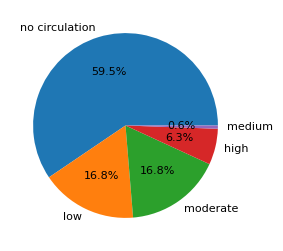

In [30]:
ds['circulation_level'].value_counts().plot.pie(**plot_pie_conf)
plt.show()

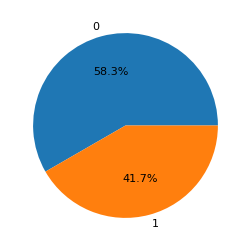

In [31]:
ds['circulation'].value_counts().plot.pie(**plot_pie_conf)
plt.show()

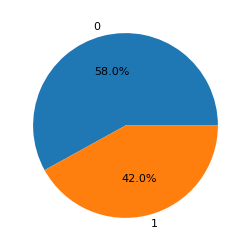

In [32]:
ds['pump_status'].value_counts().plot.pie(**plot_pie_conf)
plt.show()

## **3.2. LOSS CIRCULATION**

In [33]:
#-- well loss 
temperature_threshold = 40 # celcius
ds['circulation_loss'] = 'no_loss'

ds.loc[
    (ds['gas'] > 0) &
    (ds['mudtempout'] > temperature_threshold) &
    (ds['mudflowoutp'] > 0), 
    'circulation_loss'
] = 'partial_loss'

ds.loc[
    (ds['gas'] > 0) &
    (ds['mudtempout'] > temperature_threshold) &
    (ds['mudflowoutp'] == 0), 
    'circulation_loss'
] = 'total_loss'

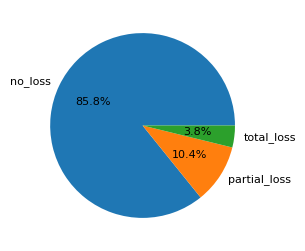

In [34]:
ds['circulation_loss'].value_counts().plot.pie(**plot_pie_conf)
plt.show()

## **3.3. STALL**

In [35]:
#-- well loss 
ds['stall'] = 0
ds.loc[(ds['torque'] > 0) & (ds['rpm'] < 1), 'stall'] = 1

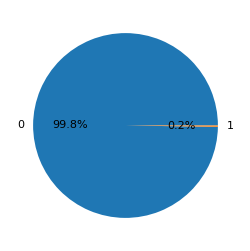

In [36]:
ds['stall'].value_counts().plot.pie(**plot_pie_conf)
plt.show()

## **3.4. BLOCK MOVEMENT**

In [37]:
#-- detect block movement
block_pos_threshold = 1.0 # meter
ds['block_movement'] = 'none'

#-- detect block velocity
ds['block_velocity'] = savgol_filter(
    ds['block_pos'],
    window_length = 11, # must be odd, 11 because 5 second interval (5 * 11 = 55 seconds / 1 minute, 00 is counted)
    polyorder = 2,
    deriv = 1,
    delta = 5
) * 60

ds.loc[
    (ds['block_velocity'] < block_pos_threshold) |
    (ds['block_velocity'] > -block_pos_threshold), 
    'block_movement'
] = 'stationary'

ds.loc[
    (ds['block_velocity'] < 0) &
    (ds['block_velocity'] < -block_pos_threshold), 
    'block_movement'
] = 'slack_off'

ds.loc[
    (ds['block_velocity'] > 0) &
    (ds['block_velocity'] > block_pos_threshold), 
    'block_movement'
] = 'pick_up'

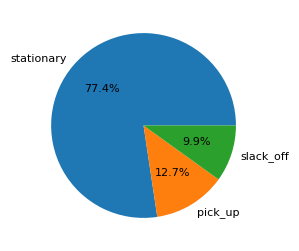

In [38]:
ds['block_movement'].value_counts().plot.pie(**plot_pie_conf)
plt.show()

## **3.5 STRING MOVEMENT**

In [39]:
ds['bit_depth_rate'] = savgol_filter(
    ds['bit_depth'],
    window_length=11, # must be odd, 11 because 5 second interval (5 * 11 = 55 seconds / 1 minute, 00 is counted)
    polyorder=2,
    deriv=1,
    delta=5 # time sample
) * 60

In [40]:
block_weight = 100 # klb
depth_threshold = 2 # feet
hookload_threshold = 1 # klb
bit_depth_rate_threshold = 2 # meter per minute

ds['diff_bit_depth']  = ds['bit_depth'].diff().bfill()
ds['hkld_roll_max']   = ds['hkld'].rolling(window=2).max().bfill()
ds['hkld_roll_min']   = ds['hkld'].rolling(window=2).min().bfill()
ds['string_movement'] = 'other'

In [41]:
#-- string out of hole
ds.loc[
    (ds['bit_depth'] == 0),
    'string_movement'
] = 'out_of_hole'

In [42]:
#-- string hangging / stationary
ds.loc[
    (ds['bit_depth'] > 0) & 
    (ds['diff_bit_depth'] <= depth_threshold) & 
    (ds['block_movement'] == 'stationary') & 
    (ds['wob'] == 0), 
    'string_movement'
] = 'hangging'

In [43]:
#-- string laid down
ds.loc[
    (ds['bit_depth'] > 0) &
    (ds['log_depth'] - ds['bit_depth'] < depth_threshold) & 
    (ds['block_movement'] == 'stationary') & 
    (ds['hkld_roll_max'] < block_weight) & 
    (ds['hkld_roll_min'] < block_weight) & 
    ((ds['hkld_roll_max'] - ds['hkld_roll_min']) < hookload_threshold) & 
    (ds['wob'] == 0), 
    'string_movement'
] = 'laid_down'

In [44]:
#-- string when drilling
ds.loc[
    (ds['bit_depth'] > 0) & 
    (ds['block_movement'] == 'stationary') & 
    (ds['hkld_roll_max'] > block_weight) & 
    (ds['hkld_roll_min'] > block_weight) & 
    (ds['ropi'] > 0) & 
    (ds['wob'] > 0), 
    'string_movement'
] = 'drilling'

In [45]:
#-- string slack off
#-- NOTES: remember, just simply because block pose move does not mean the string can always move

ds.loc[
    (ds['bit_depth'] > 0) & 
    (ds['block_movement'] == 'slack_off') & 
    (ds['hkld_roll_max'] > block_weight) & 
    (ds['wob'] == 0), 
    'string_movement'
] = 'slack_off'

In [46]:
#-- string picked up
#-- NOTES: remember, just simply because block pose move does not mean the string can always move

ds.loc[
    (ds['bit_depth'] > 0) & 
    (ds['block_movement'] == 'pick_up') & 
    (ds['hkld_roll_max'] > block_weight) & 
    (ds['wob'] == 0), 
    'string_movement'
] = 'pick_up'

In [47]:
#-- string moving up / down
ds.loc[
    (ds['bit_depth'] > 0) & 
    (ds['bit_depth_rate'] <= -bit_depth_rate_threshold) & 
    (ds['diff_bit_depth'] <= depth_threshold) & 
    (ds['block_movement'] == 'pick_up') & 
    (ds['wob'] == 0), 
    'string_movement'
] = 'pick_up'

ds.loc[
    (ds['bit_depth'] > 0) & 
    (ds['bit_depth_rate'] >= bit_depth_rate_threshold) & 
    (ds['diff_bit_depth'] <= depth_threshold) & 
    (ds['block_movement'] == 'slack_off') & 
    (ds['wob'] == 0), 
    'string_movement'
] = 'slack_off'

In [48]:
#-- string might stick
ds.loc[
    (ds['bit_depth'] > 0) & 
    (ds['block_movement'] == 'stationary') &
    (ds['hkld_roll_max'] > block_weight) &
    (ds['bit_depth_rate'] > -bit_depth_rate_threshold) & 
    (ds['bit_depth_rate'] < bit_depth_rate_threshold) &
    (ds['wob'] == 0),
    'string_movement'
] = 'high_load'

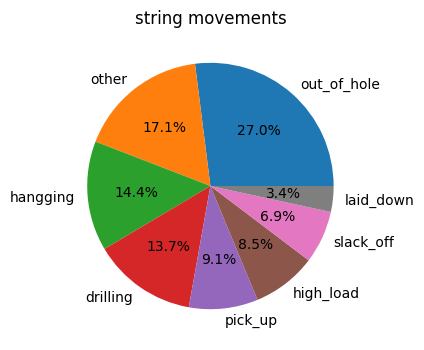

In [49]:
ds['string_movement'].value_counts().plot.pie(autopct='%1.1f%%', figsize=(4,4), ylabel='')

plt.title('string movements')
plt.show()

## **3.6 OVERPULL & DRAG**

In [50]:
ds['overpull_and_drag'] = np.where(
    #-- rules
    (ds['bit_depth'] > 0) & 
    (ds['hkld'] > block_weight) &
    (ds['hkld_roll_max'] > block_weight) &
    (ds['hkld_roll_min'] > block_weight) &
    ((ds['hkld_roll_max'] - ds['hkld_roll_min']) > 5) &
    (ds['diff_bit_depth'] > 0) & 
    (ds['diff_bit_depth'] <= depth_threshold) &
    (ds['bit_depth_rate'] > -bit_depth_rate_threshold) & 
    (ds['bit_depth_rate'] < bit_depth_rate_threshold),
    
    #-- values
    ds['hkld_roll_max'] - ds['hkld_roll_min'], 0
)

In [51]:
ds[[
    'log_depth', 'bit_depth', 'hkld', 'hkld_roll_max', 'hkld_roll_min', 'overpull_and_drag',
    'block_pos', 'wob', 'torque', 'rpm', 'block_movement', 'string_movement'
]].loc[
    (ds['bit_depth'] > 0) & 
    (ds['hkld'] > block_weight) &
    (ds['hkld_roll_max'] > block_weight) &
    (ds['hkld_roll_min'] > block_weight) &
    ((ds['hkld_roll_max'] - ds['hkld_roll_min']) > 5) &
    (ds['diff_bit_depth'] > 0) & 
    (ds['diff_bit_depth'] <= depth_threshold) &
    (ds['bit_depth_rate'] > -bit_depth_rate_threshold) & 
    (ds['bit_depth_rate'] < bit_depth_rate_threshold)
]

,log_depth,bit_depth,hkld,hkld_roll_max,hkld_roll_min,overpull_and_drag,block_pos,wob,torque,rpm,block_movement,string_movement
90131,217.0,217.4,102.8,109.7,102.8,6.9,28.4,7.0,2.4,142.0,stationary,drilling
93105,250.0,250.1,103.8,113.9,103.8,10.1,23.2,9.4,0.0,98.0,stationary,drilling
95269,273.0,272.2,105.2,112.5,105.2,7.3,1.1,0.0,0.0,98.0,slack_off,slack_off
95403,273.0,272.6,110.0,116.8,110.0,6.8,29.5,6.2,2.5,139.0,stationary,other
96716,279.0,279.0,109.2,114.8,109.2,5.6,23.2,7.0,0.0,108.0,stationary,other
...,...,...,...,...,...,...,...,...,...,...,...,...
515651,1753.0,959.7,111.1,120.1,111.1,9.0,1.5,0.0,0.0,0.0,stationary,high_load
515986,1753.0,988.5,113.4,121.0,113.4,7.6,1.6,0.0,0.0,0.0,stationary,high_load
516294,1753.0,1017.5,115.3,122.4,115.3,7.1,1.9,0.0,0.0,0.0,stationary,high_load
516353,1753.0,1017.3,105.7,116.5,105.7,10.8,30.8,0.0,0.0,0.0,stationary,high_load


## **3.7 SEVERITIES & LEVELS**

### **3.7.1 TORQUE**

In [52]:
conditions = {
    'torque' : [
        ds['torque'] < 1.0, 
        (ds['torque'] >= 1.0) & (ds['torque'] < 5.0), 
        (ds['torque'] >= 5.0) & (ds['torque'] < 10.0),
        (ds['torque'] >= 10.0) & (ds['torque'] < 15.0),
        (ds['torque'] >= 15.0) & (ds['torque'] < 20.0),
        ds['torque'] >= 20.0
    ]
}

In [53]:
levels = {
    'torque' : ['no_resistance', 'low', 'light', 'medium', 'high', 'severe'],
}

In [54]:
ds['torque_severity'] = np.select(conditions['torque'], levels['torque'], default=levels['torque'][0])

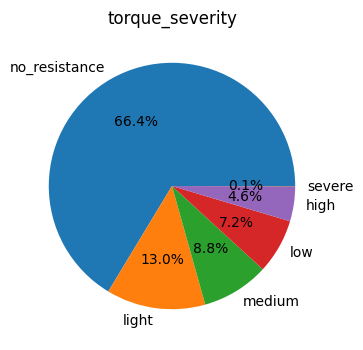

In [55]:
ds['torque_severity'].value_counts().plot.pie(autopct='%1.1f%%', figsize=(4,4), ylabel='')

plt.title('torque_severity')
plt.show()

## **3.8 STATISTICAL VALUES**

In [56]:
#-- value differences
ds['diff_rpm']     = ds['rpm'].diff().bfill()
ds['diff_ropi']    = ds['ropi'].diff().bfill()
ds['diff_torque']  = ds['torque'].diff().bfill()
ds['diff_totspm']  = ds['totspm'].diff().bfill()
ds['diff_sppress'] = ds['sppress'].diff().bfill()

In [57]:
#-- value acceleration
ds['accel_rpm']     = ds['rpm'].diff().diff().bfill()
ds['accel_ropi']    = ds['ropi'].diff().diff().bfill()
ds['accel_torque']  = ds['torque'].diff().diff().bfill()
ds['accel_totspm']  = ds['totspm'].diff().diff().bfill()
ds['accel_sppress'] = ds['sppress'].diff().diff().bfill()

In [58]:
#-- cummulative changes
ds['rpm_change']     = ds['rpm'].diff().cumsum()
ds['ropi_change']    = ds['ropi'].diff().cumsum()
ds['torque_change']  = ds['torque'].diff().cumsum()
ds['totspm_change']  = ds['totspm'].diff().cumsum()
ds['sppress_change'] = ds['sppress'].diff().cumsum()

cols_cum = ['rpm_change','ropi_change','torque_change','totspm_change','sppress_change']
for col in tqdm(cols_cum):
    ds[f'{col}_rise'] = ds[col].clip(lower=0)
    ds[f'{col}_fall'] = -ds[col].clip(upper=0)

100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 29.36it/s]


In [59]:
#-- direction of changes  
ds['rpm_rising']  = ds['diff_rpm'].clip(lower=0)
ds['rpm_falling'] = -ds['diff_rpm'].clip(upper=0)

ds['ropi_rising']  = ds['diff_ropi'].clip(lower=0)
ds['ropi_falling'] = -ds['diff_ropi'].clip(upper=0)

ds['torque_rising']  = ds['diff_torque'].clip(lower=0)
ds['torque_falling'] = -ds['diff_torque'].clip(upper=0)

ds['totspm_rising']  = ds['diff_totspm'].clip(lower=0)
ds['totspm_falling'] = -ds['diff_totspm'].clip(upper=0)

ds['sppress_rising']  = ds['diff_sppress'].clip(lower=0)
ds['sppress_falling'] = -ds['diff_sppress'].clip(upper=0)

In [60]:
#-- rolling statistics
ds['rpm_roll_std']  = ds['rpm'].rolling(12).std()
ds['rpm_roll_mean'] = ds['rpm'].rolling(12).mean()

ds['ropi_roll_std']  = ds['ropi'].rolling(12).std()
ds['ropi_roll_mean'] = ds['ropi'].rolling(12).mean()

ds['torque_roll_std']  = ds['torque'].rolling(12).std()
ds['torque_roll_mean'] = ds['torque'].rolling(12).mean()

ds['totspm_roll_std']  = ds['totspm'].rolling(12).std()
ds['totspm_roll_mean'] = ds['totspm'].rolling(12).mean()

ds['sppress_roll_std']  = ds['sppress'].rolling(12).std()
ds['sppress_roll_mean'] = ds['sppress'].rolling(12).mean()

In [61]:
ds['rop_spp_ratio'] = ds['ropi'] / ds['sppress']
ds['torque_rpm_ratio'] = ds['torque'] / ds['rpm']

In [62]:
ds['rpm_z'] = (ds['rpm'] - ds['rpm'].rolling(180).mean()) / ds['rpm'].rolling(180).std()
ds['ropi_z'] = (ds['ropi'] - ds['ropi'].rolling(180).mean()) / ds['ropi'].rolling(180).std()
ds['torque_z'] = (ds['torque'] - ds['torque'].rolling(180).mean()) / ds['torque'].rolling(180).std()
ds['totspm_z'] = (ds['totspm'] - ds['totspm'].rolling(180).mean()) / ds['totspm'].rolling(180).std()
ds['sppress_z'] = (ds['sppress'] - ds['sppress'].rolling(180).mean()) / ds['sppress'].rolling(180).std()

cols_z = ['rpm_z','ropi_z','torque_z','totspm_z','sppress_z']
for col in tqdm(cols_z):
    ds[f'{col}_rise'] = ds[col].clip(lower=0)
    ds[f'{col}_fall'] = -ds[col].clip(upper=0)

100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 29.39it/s]


In [63]:
#-- rate of change
ds['rpm_roc']     = ds['diff_rpm'] / ds['rpm'].shift(1).bfill() 
ds['ropi_roc']    = ds['diff_ropi'] / ds['ropi'].shift(1).bfill() 
ds['torque_roc']  = ds['diff_torque'] / ds['torque'].shift(1).bfill() 
ds['totspm_roc']  = ds['diff_totspm'] / ds['totspm'].shift(1).bfill() 
ds['sppress_roc'] = ds['diff_sppress'] / ds['sppress'].shift(1).bfill()

cols_z = ['rpm_roc','ropi_roc','torque_roc','totspm_roc','sppress_roc']
for col in tqdm(cols_z):
    ds[f'{col}_rise'] = ds[col].clip(lower=0)
    ds[f'{col}_fall'] = -ds[col].clip(upper=0)

100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 28.57it/s]


In [64]:
ds.replace([np.inf, -np.inf], np.nan, inplace=True)
ds.fillna(0, inplace=True)

## **3.9 ENCODING**

In [65]:
#-- ordinal encoding
cat_ord = {
    'circulation_level' : {'no circulation': 0, 'low': 1, 'moderate': 2, 'medium': 3, 'high': 4},
    'torque_severity'   : {'no_resistance': 0, 'light': 1, 'low': 2, 'medium': 3, 'high': 4, 'severe': 5}
}

for key, value in tqdm(cat_ord.items()):
    ds[key] = ds[key].map(value)

100%|████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00,  9.65it/s]


In [66]:
#-- one hot encoding
cat = ds.select_dtypes(include=['object','category']).columns

for col in cat:
    mlb = MultiLabelBinarizer()
    ds[col] = ds[col].str.split(',')
    encoded = mlb.fit_transform(ds[col])
    encoded_df = pd.DataFrame(encoded, columns=[f"{col}_{cls}" for cls in mlb.classes_], index=ds.index)
    ds = ds.drop(columns=[col]).join(encoded_df)

In [67]:
lb = ds['stuck']
ds = ds.drop(columns=['stuck'])
ds['stuck'] = lb

In [68]:
print(f'data shape      : {ds.shape}')
print(f"data labels     : {list(ds[ds.columns[-1]].value_counts())}")
print(f'data duplicates : {ds[ds.columns[0]].duplicated().sum()}')
print(f'data nan values : \n\n{ds.isna().sum()}\n')

data shape      : (562729, 127)
data labels     : [557442, 5287]
data duplicates : 3302
data nan values : 

date_time                      0
log_depth                      0
bit_depth                      0
block_pos                      0
wob                            0
                              ..
string_movement_other          0
string_movement_out_of_hole    0
string_movement_pick_up        0
string_movement_slack_off      0
stuck                          0
Length: 127, dtype: int64



In [69]:
print(f'data maxs : \n{ds[ds.columns[1:]].max()}\n')
print(f'data mins : \n{ds[ds.columns[1:]].min()}\n')

data maxs : 
log_depth                      1753.0
bit_depth                      1753.1
block_pos                        51.3
wob                             127.8
torque                           38.8
                                ...  
string_movement_other             1.0
string_movement_out_of_hole       1.0
string_movement_pick_up           1.0
string_movement_slack_off         1.0
stuck                             1.0
Length: 126, dtype: float64

data mins : 
log_depth                      0.0
bit_depth                      0.0
block_pos                      0.0
wob                            0.0
torque                         0.0
                              ... 
string_movement_other          0.0
string_movement_out_of_hole    0.0
string_movement_pick_up        0.0
string_movement_slack_off      0.0
stuck                          0.0
Length: 126, dtype: float64



In [70]:
# del df

In [71]:
list(ds.columns)

['date_time',
 'log_depth',
 'bit_depth',
 'block_pos',
 'wob',
 'torque',
 'hkld',
 'rpm',
 'ropi',
 'mse',
 'sppress',
 'totspm',
 'mudflowin',
 'mudflowoutp',
 'mudtempin',
 'mudtempout',
 'tankvoltot',
 'gas',
 'bvdepth',
 'binclination',
 'bazimuth',
 'dazimuth',
 'dinclination',
 'dvdepth',
 'pump_status',
 'circulation',
 'circulation_level',
 'stall',
 'block_velocity',
 'bit_depth_rate',
 'diff_bit_depth',
 'hkld_roll_max',
 'hkld_roll_min',
 'overpull_and_drag',
 'torque_severity',
 'diff_rpm',
 'diff_ropi',
 'diff_torque',
 'diff_totspm',
 'diff_sppress',
 'accel_rpm',
 'accel_ropi',
 'accel_torque',
 'accel_totspm',
 'accel_sppress',
 'rpm_change',
 'ropi_change',
 'torque_change',
 'totspm_change',
 'sppress_change',
 'rpm_change_rise',
 'rpm_change_fall',
 'ropi_change_rise',
 'ropi_change_fall',
 'torque_change_rise',
 'torque_change_fall',
 'totspm_change_rise',
 'totspm_change_fall',
 'sppress_change_rise',
 'sppress_change_fall',
 'rpm_rising',
 'rpm_falling',
 'ropi_

# **4. TRAINING DATA**

## **4.1. SLIDING WINDOW**

In [72]:
del df

In [73]:
features = [
    # base data
    'block_pos', 'wob', 'torque','hkld', 'rpm', 'ropi', 'mse', 'sppress', 
    'totspm', 'mudflowin', 'mudflowoutp', 'mudtempin', 'mudtempout', 'tankvoltot', 'gas',

    # domain knowledge
    'pump_status', 'circulation', 'circulation_level', 'stall', 'hkld_roll_max', 'hkld_roll_min', 
    'overpull_and_drag', 'torque_severity', 'circulation_loss_no_loss', 'circulation_loss_partial_loss', 
    'circulation_loss_total_loss', 'block_movement_pick_up', 'block_movement_slack_off', 'block_movement_stationary', 
    'string_movement_drilling', 'string_movement_hangging', 'string_movement_high_load', 'string_movement_laid_down', 
    'string_movement_other', 'string_movement_out_of_hole', 'string_movement_pick_up', 'string_movement_slack_off',

    # statistical data
    'rpm_change_rise', 'rpm_change_fall', 'ropi_change_rise', 'ropi_change_fall', 'torque_change_rise', 
    'torque_change_fall', 'totspm_change_rise', 'totspm_change_fall', 'sppress_change_rise', 'sppress_change_fall',
    'rpm_rising', 'rpm_falling', 'ropi_rising', 'ropi_falling', 'torque_rising', 'torque_falling', 'totspm_rising', 
    'totspm_falling', 'sppress_rising', 'sppress_falling',
    'rpm_roll_std', 'rpm_roll_mean', 'ropi_roll_std', 'ropi_roll_mean', 'torque_roll_std', 'torque_roll_mean', 
    'totspm_roll_std', 'totspm_roll_mean', 'sppress_roll_std', 'sppress_roll_mean', 'rop_spp_ratio', 'torque_rpm_ratio',
    'rpm_z_rise', 'rpm_z_fall', 'ropi_z_rise', 'ropi_z_fall', 'torque_z_rise', 'torque_z_fall', 'totspm_z_rise', 'totspm_z_fall', 
    'sppress_z_rise', 'sppress_z_fall', 'rpm_roc_rise', 'rpm_roc_fall', 'ropi_roc_rise', 'ropi_roc_fall', 'torque_roc_rise', 
    'torque_roc_fall', 'totspm_roc_rise', 'totspm_roc_fall', 'sppress_roc_rise', 'sppress_roc_fall',

    'stuck'
]

In [74]:
fet_con = [
    'block_pos', 'wob', 'torque','hkld', 'rpm', 'ropi', 'mse', 'sppress', 
    'totspm', 'mudflowin', 'mudflowoutp', 'mudtempin', 'mudtempout', 'tankvoltot', 'gas',

    'circulation_level', 'hkld_roll_max', 'hkld_roll_min', 'overpull_and_drag', 'torque_severity',

    'rpm_change_rise', 'rpm_change_fall', 'ropi_change_rise', 'ropi_change_fall', 'torque_change_rise', 
    'torque_change_fall', 'totspm_change_rise', 'totspm_change_fall', 'sppress_change_rise', 'sppress_change_fall',
    'rpm_rising', 'rpm_falling', 'ropi_rising', 'ropi_falling', 'torque_rising', 'torque_falling', 'totspm_rising', 
    'totspm_falling', 'sppress_rising', 'sppress_falling',
    'rpm_roll_std', 'rpm_roll_mean', 'ropi_roll_std', 'ropi_roll_mean', 'torque_roll_std', 'torque_roll_mean', 
    'totspm_roll_std', 'totspm_roll_mean', 'sppress_roll_std', 'sppress_roll_mean', 'rop_spp_ratio', 'torque_rpm_ratio',
    'rpm_z_rise', 'rpm_z_fall', 'ropi_z_rise', 'ropi_z_fall', 'torque_z_rise', 'torque_z_fall', 'totspm_z_rise', 
    'totspm_z_fall', 'sppress_z_rise', 'sppress_z_fall', 'rpm_roc_rise', 'rpm_roc_fall', 'ropi_roc_rise', 'ropi_roc_fall', 
    'torque_roc_rise', 'torque_roc_fall', 'totspm_roc_rise', 'totspm_roc_fall', 'sppress_roc_rise', 'sppress_roc_fall', 

    'stuck'
]
fet_cat = [
    'pump_status', 'circulation', 'stall', 'circulation_loss_no_loss', 'circulation_loss_partial_loss', 
    'circulation_loss_total_loss', 'block_movement_pick_up', 'block_movement_slack_off', 'block_movement_stationary', 
    'string_movement_drilling', 'string_movement_hangging', 'string_movement_high_load', 'string_movement_laid_down', 
    'string_movement_other', 'string_movement_out_of_hole', 'string_movement_pick_up', 'string_movement_slack_off',

    'stuck'
]

In [75]:
for key, value in ds[features].min().to_dict().items():
    if value < 0:
        print(key, value)

In [76]:
for feat in fet_con:
    if feat in fet_cat:
        print(feat)

stuck


In [77]:
for feat in features:
    if feat not in fet_con:
        if feat not in fet_cat:
            print(feat)

    if feat not in fet_cat:
        if feat not in fet_con:
            print(feat)


In [78]:
X_con = ds.set_index(ds.columns[0])[fet_con].astype("float32").values
X_cat = ds.set_index(ds.columns[0])[fet_cat].astype("float32").values

In [79]:
step_in  = 60
step_out = 60

X_con, y_con = split_sequences(X_con, step_in, step_out)
X_cat, y_cat = split_sequences(X_cat, step_in, step_out)

100%|█████████████████████████████████████████████████████████████████████▉| 562610/562729 [00:01<00:00, 396284.18it/s]


In [80]:
y_con = y_con.astype(np.int8)
y_cat = y_cat.astype(np.int8)

In [81]:
X_con.shape, X_cat.shape

((562610, 60, 72), (562610, 60, 17))

In [82]:
y_con.shape, y_cat.shape

((562610,), (562610,))

In [83]:
print(np.unique(y_con, return_counts=True))
print(np.unique(y_cat, return_counts=True))

(array([0, 1], dtype=int8), array([557323,   5287]))
(array([0, 1], dtype=int8), array([557323,   5287]))


## **4.2. SPLIT DATASETS**

In [84]:
split_point = 0.855
split_point_con = int((len(X_con) - step_in + 1) * split_point)
split_point_cat = int((len(X_cat) - step_in + 1) * split_point)

split_point_con, split_point_cat

(480981, 480981)

In [85]:
#-- split dataset
X_con_train, X_con_test = X_con[:split_point_con], X_con[split_point_con:]
y_con_train, y_con_test = y_con[:split_point_con], y_con[split_point_con:]
del X_con, y_con

X_cat_train, X_cat_test = X_cat[:split_point_cat], X_cat[split_point_cat:]
y_cat_train, y_cat_test = y_cat[:split_point_cat], y_cat[split_point_cat:]
del X_cat, y_cat

In [86]:
print(f'continous shape : {X_con_train.shape, X_con_test.shape}')
print(f'static shape    : {X_cat_train.shape, X_cat_test.shape}')

continous shape : ((480981, 60, 72), (81629, 60, 72))
static shape    : ((480981, 60, 17), (81629, 60, 17))


In [87]:
print(np.unique(y_con_train, return_counts=True))
print(np.unique(y_cat_train, return_counts=True))

(array([0, 1], dtype=int8), array([478892,   2089]))
(array([0, 1], dtype=int8), array([478892,   2089]))


In [88]:
print(np.unique(y_con_test, return_counts=True))
print(np.unique(y_cat_test, return_counts=True))

(array([0, 1], dtype=int8), array([78431,  3198]))
(array([0, 1], dtype=int8), array([78431,  3198]))


## **4.3. SCALING**

In [89]:
def scale_data_min_max(arr, max_vals, min_vals, batch_size = 10000):
    range_vals = max_vals - min_vals
    constant_mask = range_vals == 0
    range_vals[constant_mask] = 1
    
    for i in tqdm(range(0, arr.shape[0], batch_size)):
        arr[i:i+batch_size] = (arr[i:i+batch_size] - min_vals) / range_vals
    
    arr[:, constant_mask] = 0

    return arr

In [90]:
min_vals = X_con_train.min(axis=0)
max_vals = X_con_train.max(axis=0)

X_con_train = scale_data_min_max(X_con_train, max_vals, min_vals)
X_con_test  = scale_data_min_max(X_con_test, max_vals, min_vals)

100%|████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:02<00:00,  3.05it/s]


In [91]:
min_vals = X_cat_train.min(axis=0)
max_vals = X_cat_train.max(axis=0)

X_cat_train = scale_data_min_max(X_cat_train, max_vals, min_vals)
X_cat_test  = scale_data_min_max(X_cat_test, max_vals, min_vals)

100%|████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 10.39it/s]


In [92]:
X_train = np.concatenate([X_con_train, X_cat_train], axis=2)
X_test  = np.concatenate([X_con_test, X_cat_test], axis=2)
y_train = y_con_train
y_test  = y_con_test

In [93]:
del X_con_train, X_cat_train, X_con_test, X_cat_test, y_con_train, y_con_test

In [94]:
print(f'X_train : {X_train.shape}')
print(f'y_train : {y_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'y_test  : {y_train.shape}')

X_train : (480981, 60, 89)
y_train : (480981,)
X_test  : (81629, 60, 89)
y_test  : (480981,)


In [95]:
print(f'class_train : {np.unique(y_train, return_counts=True)}')
print(f'class_test  : {np.unique(y_test, return_counts=True)}\n')

class_train : (array([0, 1], dtype=int8), array([478892,   2089]))
class_test  : (array([0, 1], dtype=int8), array([78431,  3198]))



## **4.4. SAVE DATASET**

In [113]:
#-- get directories
name = Path(datasets[0]).stem
train_path = os.path.join(data_train_path, f"{name}_train_{step_in}{step_out}.h5")
test_path  = os.path.join(data_test_path, f"{name}_test_{step_in}{step_out}.h5")

train_path, test_path

('E:\\Jupyter\\manannan\\stuck-prediction-v2\\datasets_training\\1. KMJ-69.4_train_6060.h5',
 'E:\\Jupyter\\manannan\\stuck-prediction-v2\\datasets_testing\\1. KMJ-69.4_test_6060.h5')

In [114]:
#-- save training data
n_samples, timesteps, features = X_train.shape
batch_size = 10000

with h5py.File(train_path, "w") as f:
    dset_X = f.create_dataset(
        "X", shape=(n_samples, timesteps, features),
        dtype="float32", compression="gzip", chunks=(batch_size, timesteps, features)
    )
    dset_y = f.create_dataset(
        "y", shape=(n_samples,),
        dtype="float16", compression="gzip", chunks=(batch_size,)
    )

    for i in tqdm(range(0, n_samples, batch_size)):
        end = min(i + batch_size, n_samples)

        X_batch = X_train[i:end]
        y_batch = y_train[i:end]

        dset_X[i:end] = X_batch
        dset_y[i:end] = y_batch

100%|██████████████████████████████████████████████████████████████████████████████████| 49/49 [01:14<00:00,  1.51s/it]


In [115]:
#-- save test data
n_samples, timesteps, features = X_test.shape
batch_size = 1000

with h5py.File(test_path, "w") as f:
    dset_X = f.create_dataset(
        "X", shape=(n_samples, timesteps, features),
        dtype="float32", compression="gzip", chunks=(batch_size, timesteps, features)
    )
    dset_y = f.create_dataset(
        "y", shape=(n_samples,),
        dtype="float16", compression="gzip", chunks=(batch_size,)
    )

    for i in range(0, n_samples, batch_size):
        end = min(i + batch_size, n_samples)

        X_batch = X_test[i:end]
        y_batch = y_test[i:end]

        dset_X[i:end] = X_batch
        dset_y[i:end] = y_batch